# Exploratory Data Analysis (EDA) - Student Performance Dataset

**Nama dataset:** Student Performance Dataset  
**Sumber utama:** UCI Machine Learning Repository  
**File yang digunakan:** `student-mat.csv` dari GitHub raw URL  
**Tujuan EDA:** Melihat gambaran umum data performa siswa dan mencari insight awal terkait nilai akhir siswa (`G3`).

Dataset ini berisi data performa siswa sekolah menengah di Portugal. Atributnya mencakup nilai siswa, data demografis, sosial, dan informasi sekolah. Target utama yang diamati pada EDA ini adalah `G3`, yaitu nilai akhir siswa pada mata pelajaran Matematika.


In [1]:
# Install library tambahan jika diperlukan
# Di Google Colab, pandas dan matplotlib biasanya sudah tersedia.
# Jika belum, jalankan:
# !pip install pandas matplotlib numpy


In [2]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Agar tampilan tabel lebih nyaman
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)


## 1. Load Dataset

Dataset diambil dari GitHub raw URL agar mudah dijalankan di Google Colab tanpa perlu upload file manual.


In [3]:
# URL dataset Student Performance - Mathematics
url = "https://raw.githubusercontent.com/arunk13/MSDA-Assignments/master/IS607Fall2015/Assignment3/student-mat.csv"

# Dataset menggunakan separator titik koma (;)
df = pd.read_csv(url, sep=';')

# Menampilkan 5 baris pertama
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


## 2. Memahami Struktur Data

Bagian ini digunakan untuk melihat jumlah baris, jumlah kolom, tipe data, dan apakah ada nilai kosong.


In [4]:
# Melihat ukuran dataset
print("Jumlah baris dan kolom:", df.shape)

# Informasi tipe data setiap kolom
df.info()


Jumlah baris dan kolom: (395, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 

In [5]:
# Mengecek nilai kosong
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]


,0


In [6]:
# Statistik deskriptif untuk kolom numerik
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


**Catatan awal:**  
Jika hasil pengecekan missing value kosong, artinya tidak ada nilai kosong pada dataset. Ini membuat EDA lebih sederhana karena tidak perlu imputasi data hilang.


## 3. Distribusi Nilai Akhir Siswa (`G3`)

`G3` adalah nilai akhir siswa. Nilai ini menjadi fokus utama dalam eksplorasi.


In [7]:
# Statistik ringkas nilai akhir
print("Rata-rata G3:", round(df['G3'].mean(), 2))
print("Median G3:", df['G3'].median())
print("Nilai minimum G3:", df['G3'].min())
print("Nilai maksimum G3:", df['G3'].max())

# Menghitung persentase siswa dengan nilai akhir >= 10
pass_rate = (df['G3'] >= 10).mean() * 100
print("Persentase siswa dengan G3 >= 10:", round(pass_rate, 2), "%")


Rata-rata G3: 10.42
Median G3: 11.0
Nilai minimum G3: 0
Nilai maksimum G3: 20
Persentase siswa dengan G3 >= 10: 67.09 %


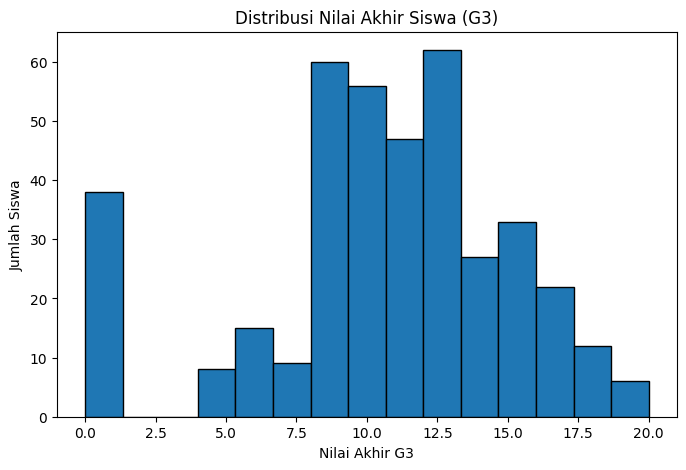

In [8]:
# Visualisasi distribusi nilai akhir
plt.figure(figsize=(8, 5))
plt.hist(df['G3'], bins=15, edgecolor='black')
plt.title('Distribusi Nilai Akhir Siswa (G3)')
plt.xlabel('Nilai Akhir G3')
plt.ylabel('Jumlah Siswa')
plt.show()


**Insight sementara:**  
Sebagian besar nilai akhir siswa berada di sekitar nilai menengah. Rata-rata `G3` dapat digunakan sebagai gambaran umum performa akademik siswa pada dataset ini.


## 4. Korelasi Antar Variabel Numerik

Korelasi digunakan untuk melihat hubungan linear antara variabel numerik dengan nilai akhir `G3`.


In [9]:
# Memilih kolom numerik
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Korelasi dengan G3
corr_with_g3 = numeric_df.corr()['G3'].sort_values(ascending=False)
corr_with_g3


,G3
G3,1.000000
G2,0.904868
G1,0.801468
Medu,0.217147
Fedu,0.152457
studytime,0.097820
famrel,0.051363
absences,0.034247
freetime,0.011307
Walc,-0.051939


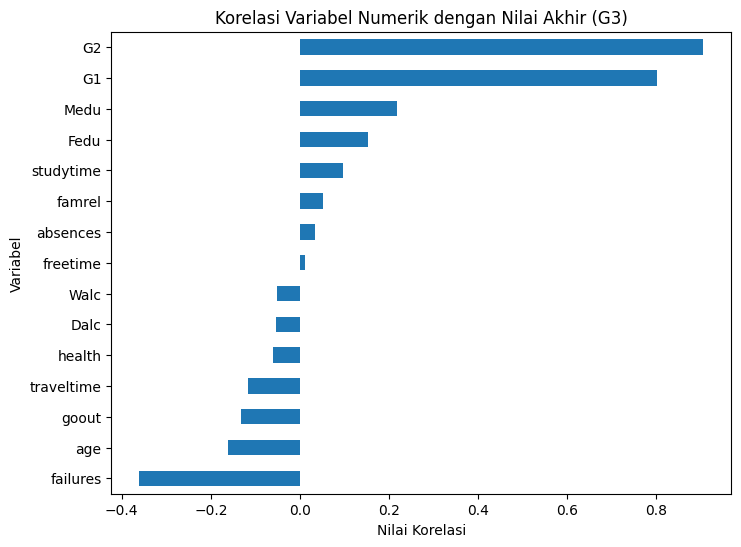

In [10]:
# Visualisasi korelasi variabel numerik dengan G3
corr_with_g3.drop('G3').sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Korelasi Variabel Numerik dengan Nilai Akhir (G3)')
plt.xlabel('Nilai Korelasi')
plt.ylabel('Variabel')
plt.show()


**Insight sementara:**  
Nilai periode sebelumnya, yaitu `G1` dan `G2`, biasanya memiliki hubungan paling kuat dengan nilai akhir `G3`. Ini masuk akal karena nilai akhir sangat berkaitan dengan performa siswa pada periode sebelumnya.


## 5. Hubungan `G2` dengan `G3`

Karena korelasi `G2` dengan `G3` biasanya tinggi, bagian ini melihat pola hubungan keduanya.


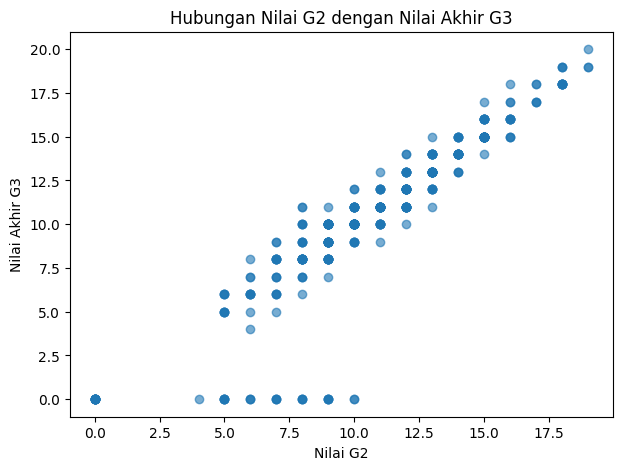

In [11]:
# Scatter plot G2 vs G3
plt.figure(figsize=(7, 5))
plt.scatter(df['G2'], df['G3'], alpha=0.6)
plt.title('Hubungan Nilai G2 dengan Nilai Akhir G3')
plt.xlabel('Nilai G2')
plt.ylabel('Nilai Akhir G3')
plt.show()


**Insight sementara:**  
Terlihat pola positif antara `G2` dan `G3`. Siswa dengan nilai `G2` tinggi cenderung memiliki nilai akhir `G3` yang tinggi juga.


## 6. Pengaruh Waktu Belajar terhadap Nilai Akhir

Kolom `studytime` menunjukkan waktu belajar mingguan siswa:
- 1 = kurang dari 2 jam
- 2 = 2 sampai 5 jam
- 3 = 5 sampai 10 jam
- 4 = lebih dari 10 jam


In [12]:
# Rata-rata G3 berdasarkan studytime
studytime_summary = df.groupby('studytime')['G3'].agg(['count', 'mean', 'median'])
studytime_summary


,count,mean,median
studytime,,,
1,105,10.047619,10.0
2,198,10.171717,11.0
3,65,11.400000,12.0
4,27,11.259259,12.0


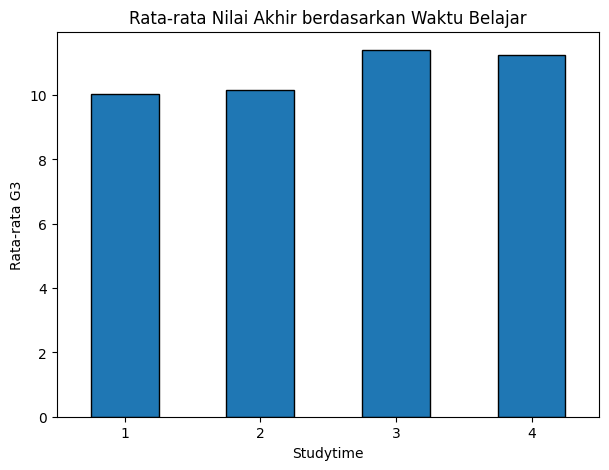

In [13]:
# Visualisasi rata-rata G3 berdasarkan studytime
studytime_summary['mean'].plot(kind='bar', figsize=(7, 5), edgecolor='black')
plt.title('Rata-rata Nilai Akhir berdasarkan Waktu Belajar')
plt.xlabel('Studytime')
plt.ylabel('Rata-rata G3')
plt.xticks(rotation=0)
plt.show()


**Insight sementara:**  
Kelompok siswa dengan waktu belajar lebih tinggi cenderung memiliki rata-rata nilai akhir yang lebih baik, meskipun perbedaannya tidak selalu sangat besar.


## 7. Riwayat Kegagalan Kelas dan Nilai Akhir

Kolom `failures` menunjukkan jumlah kegagalan kelas sebelumnya. Bagian ini melihat apakah riwayat kegagalan berkaitan dengan nilai akhir.


In [14]:
# Rata-rata G3 berdasarkan jumlah kegagalan sebelumnya
failures_summary = df.groupby('failures')['G3'].agg(['count', 'mean', 'median'])
failures_summary


,count,mean,median
failures,,,
0,312,11.253205,11.0
1,50,8.120000,9.0
2,17,6.235294,8.0
3,16,5.687500,7.0


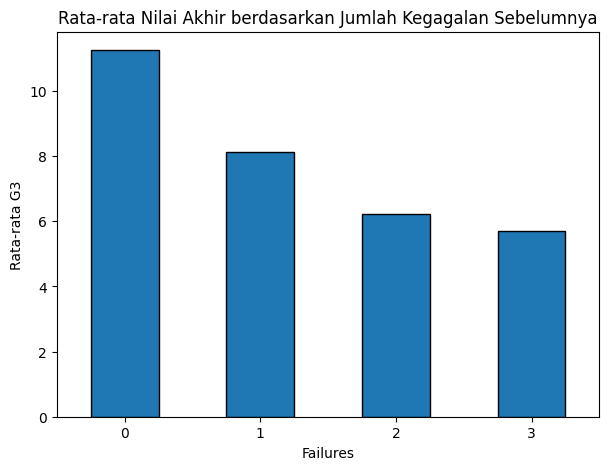

In [15]:
# Visualisasi rata-rata G3 berdasarkan failures
failures_summary['mean'].plot(kind='bar', figsize=(7, 5), edgecolor='black')
plt.title('Rata-rata Nilai Akhir berdasarkan Jumlah Kegagalan Sebelumnya')
plt.xlabel('Failures')
plt.ylabel('Rata-rata G3')
plt.xticks(rotation=0)
plt.show()


**Insight sementara:**  
Siswa yang tidak memiliki riwayat kegagalan kelas sebelumnya cenderung memiliki rata-rata nilai akhir lebih tinggi. Semakin banyak kegagalan sebelumnya, rata-rata `G3` terlihat menurun.


## 8. Perbandingan Berdasarkan Akses Internet dan Keinginan Kuliah

Bagian ini membandingkan rata-rata nilai akhir berdasarkan beberapa variabel kategorikal.


In [16]:
# Fungsi sederhana untuk menampilkan ringkasan kategorikal terhadap G3
def categorical_summary(column):
    return df.groupby(column)['G3'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False)

categorical_summary('internet')


,count,mean,median
internet,,,
yes,329,10.617021,11.0
no,66,9.409091,10.0


In [17]:
categorical_summary('higher')


,count,mean,median
higher,,,
yes,375,10.608,11.0
no,20,6.800,8.0


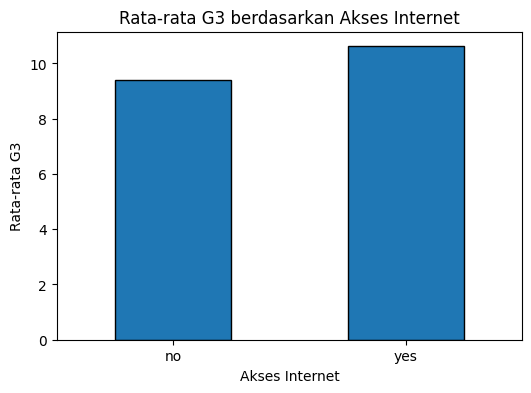

In [18]:
# Visualisasi rata-rata G3 berdasarkan akses internet
internet_mean = df.groupby('internet')['G3'].mean()

internet_mean.plot(kind='bar', figsize=(6, 4), edgecolor='black')
plt.title('Rata-rata G3 berdasarkan Akses Internet')
plt.xlabel('Akses Internet')
plt.ylabel('Rata-rata G3')
plt.xticks(rotation=0)
plt.show()


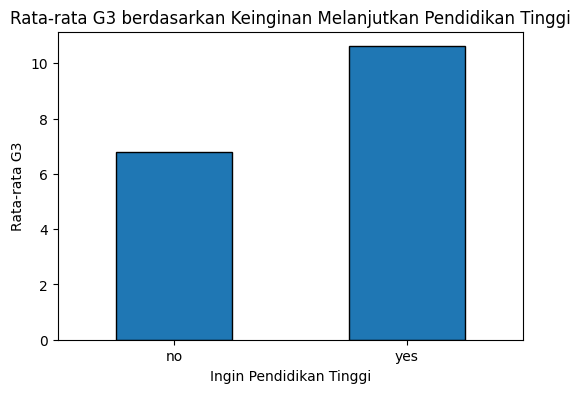

In [19]:
# Visualisasi rata-rata G3 berdasarkan keinginan melanjutkan pendidikan tinggi
higher_mean = df.groupby('higher')['G3'].mean()

higher_mean.plot(kind='bar', figsize=(6, 4), edgecolor='black')
plt.title('Rata-rata G3 berdasarkan Keinginan Melanjutkan Pendidikan Tinggi')
plt.xlabel('Ingin Pendidikan Tinggi')
plt.ylabel('Rata-rata G3')
plt.xticks(rotation=0)
plt.show()


**Insight sementara:**  
Siswa yang memiliki akses internet di rumah cenderung memiliki rata-rata nilai akhir sedikit lebih tinggi. Selain itu, siswa yang ingin melanjutkan pendidikan tinggi memiliki rata-rata `G3` lebih baik dibandingkan siswa yang tidak ingin melanjutkan pendidikan tinggi.


## 9. Kesimpulan Singkat EDA

Berdasarkan eksplorasi awal:

1. Dataset memiliki **395 baris dan 33 kolom**.
2. Tidak ditemukan missing value, sehingga data relatif siap untuk dianalisis.
3. Nilai akhir siswa (`G3`) berada pada rentang 0 sampai 20.
4. Variabel `G1` dan `G2` memiliki hubungan paling kuat dengan nilai akhir `G3`.
5. Siswa tanpa riwayat kegagalan kelas sebelumnya cenderung memiliki nilai akhir lebih tinggi.
6. Waktu belajar yang lebih tinggi cenderung berkaitan dengan nilai akhir yang lebih baik.
7. Akses internet dan keinginan melanjutkan pendidikan tinggi juga tampak berkaitan dengan rata-rata nilai akhir yang lebih tinggi.

**Catatan:**  
EDA ini hanya menunjukkan pola awal, bukan membuktikan hubungan sebab-akibat. Untuk analisis lebih lanjut, bisa dilakukan pemodelan prediksi nilai akhir siswa menggunakan machine learning.
